In [12]:
from evaluation.portfolio import portfolio_roi, portfolio_breakdown
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

abt = pd.read_parquet('C:/Users/twluc/frame/01_data/03_abt/abt.parquet')

abt['mrkt_home_away_impl_diff'] = abt['mrkt_away_impl'] - abt['mrkt_home_impl']

In [2]:
def plot_impl_groups(data, group_col):

    d = data[['mrkt_home_away_impl_diff','mrkt_home_impl','mrkt_draw_impl','mrkt_away_impl','t_result', group_col]].dropna().copy()

    order = d[group_col].value_counts().index.tolist()

    plt.figure(figsize=(13, 6))
    total = len(d)

    for grp_val in order:
        grp = d[d[group_col] == grp_val]
        pct = len(grp) / total * 100
        plt.scatter(grp['mrkt_home_away_impl_diff'], grp['mrkt_draw_impl'],
                    label=f'{grp_val} ({pct:.1f}%)',
                    alpha=0.3, s=8)

    plt.xlim(-1, 1)
    plt.ylim(0,0.4)
    plt.axvline(0, color='black', linewidth=0.8, linestyle='--')

    plt.xlabel('home / away implied probability advantage')
    plt.ylabel('draw implied probability')

    plt.legend(markerscale=3, fontsize=8)
    plt.tight_layout()
    plt.show()

    for grp_val in order:
        grp = d[d[group_col] == grp_val]
        sub = grp['t_result'].value_counts(normalize=True)
        print(f'{len(grp):4d} {str(grp_val):20s} '
              f'H: {sub.get("H", 0):5.1%} ({portfolio_roi(grp["mrkt_home_impl"], (grp["t_result"]=="H").astype(int))["roi"]:+6.1%})  '
              f'D: {sub.get("D", 0):5.1%} ({portfolio_roi(grp["mrkt_draw_impl"], (grp["t_result"]=="D").astype(int))["roi"]:+6.1%})  '
              f'A: {sub.get("A", 0):5.1%} ({portfolio_roi(grp["mrkt_away_impl"], (grp["t_result"]=="A").astype(int))["roi"]:+6.1%})')



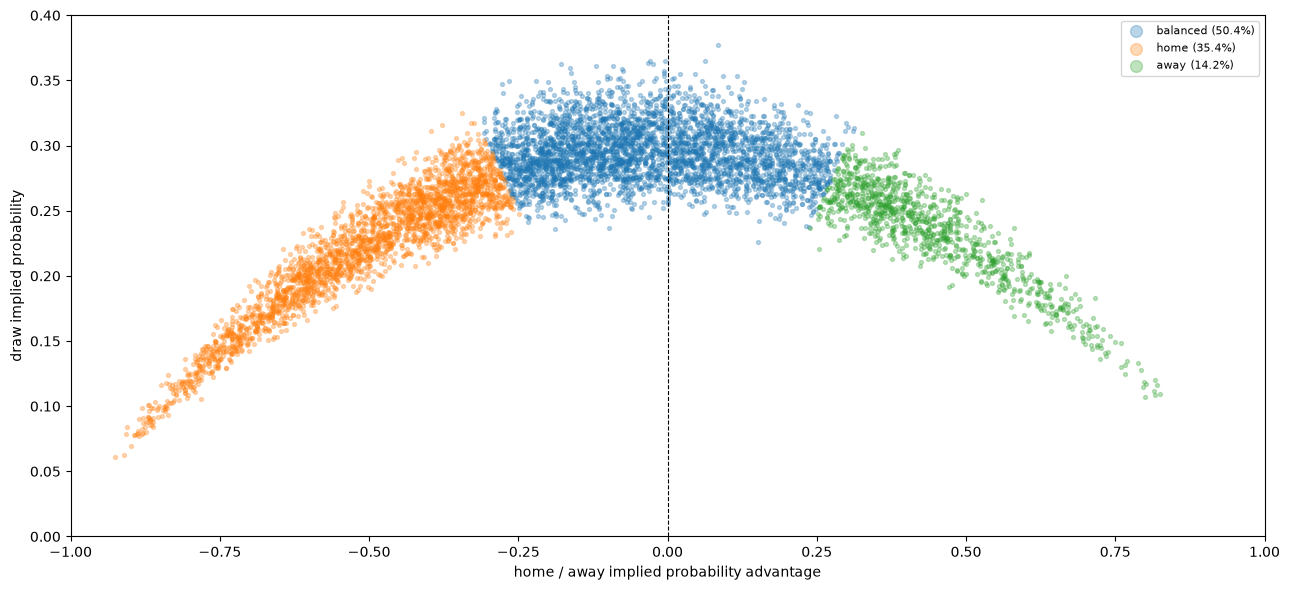

3570 balanced             H: 37.0% ( -6.2%)  D: 28.8% ( -2.1%)  A: 34.1% ( -5.3%)
2507 home                 H: 65.1% ( -2.5%)  D: 21.3% ( -3.4%)  A: 13.6% (-15.7%)
1004 away                 H: 14.3% (-23.0%)  D: 22.4% ( -4.2%)  A: 63.2% ( +0.5%)


In [3]:
plot_impl_groups(abt,'mrkt_favourite')

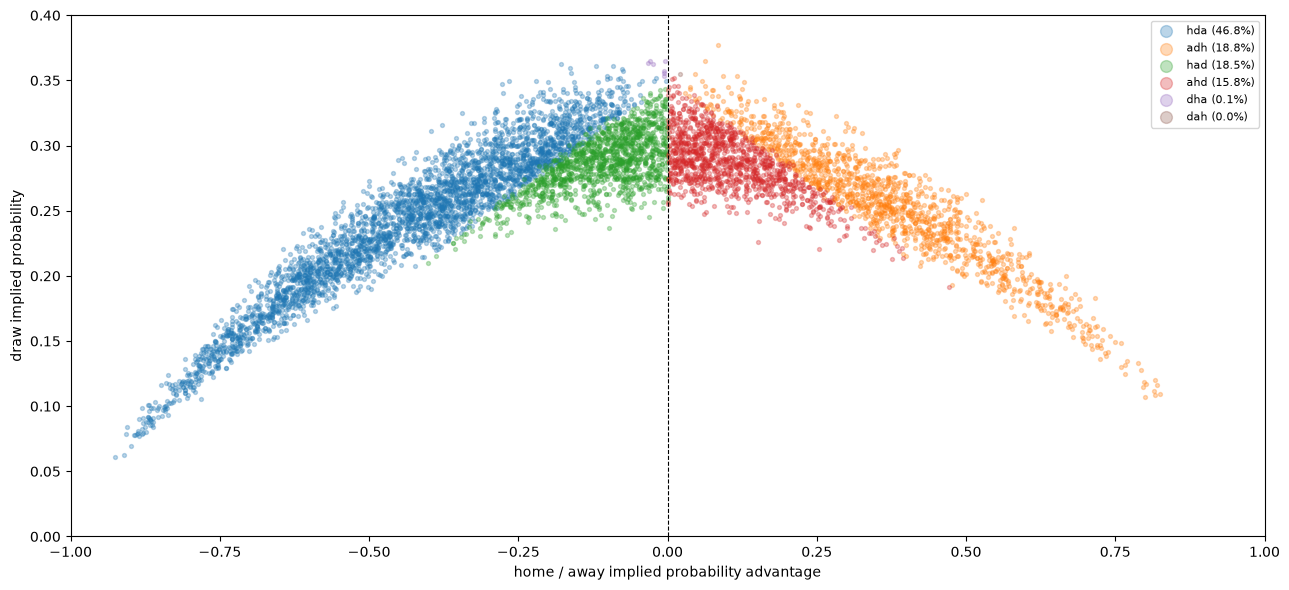

3314 hda                  H: 60.6% ( -2.0%)  D: 23.6% ( -2.5%)  A: 15.8% (-16.7%)
1332 adh                  H: 17.0% (-18.7%)  D: 24.0% ( -5.2%)  A: 58.9% ( +0.5%)
1309 had                  H: 41.3% ( -5.4%)  D: 28.2% ( -1.7%)  A: 30.6% ( -6.6%)
1118 ahd                  H: 28.3% (-14.1%)  D: 28.0% ( -2.1%)  A: 43.7% ( +0.6%)
   7 dha                  H: 71.4% (+103.3%)  D: 28.6% (-20.7%)  A:  0.0% (-100.0%)
   1 dah                  H:  0.0% (-100.0%)  D: 100.0% (+182.0%)  A:  0.0% (-100.0%)


In [4]:
plot_impl_groups(abt,'mrkt_impl_order')

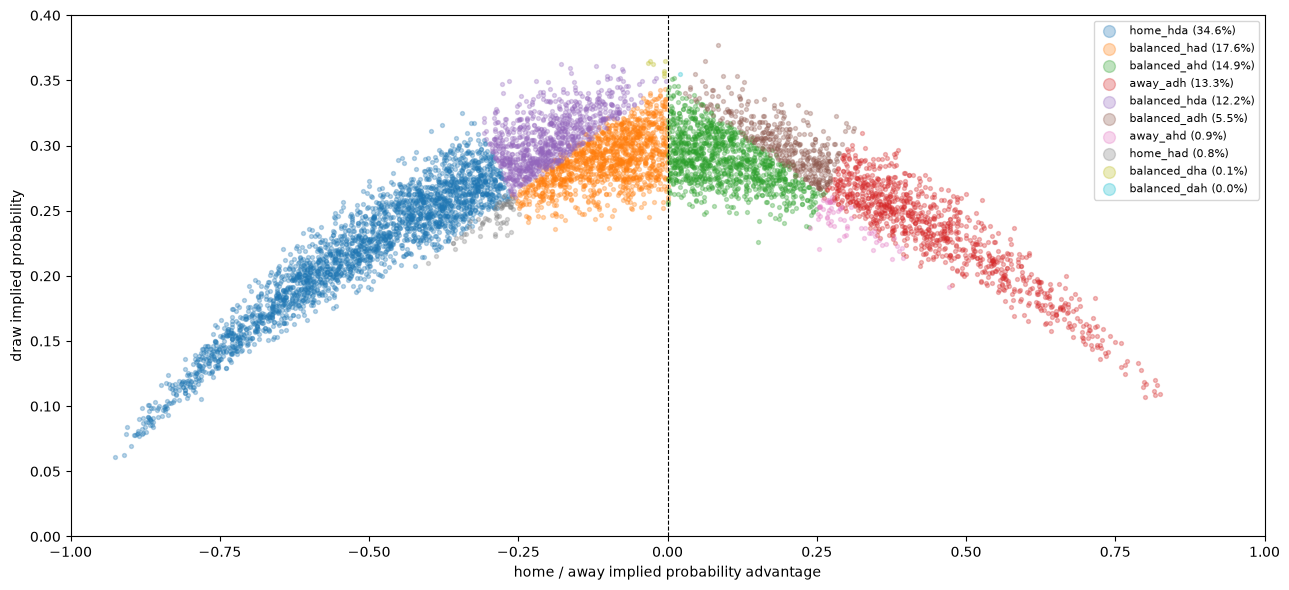

2447 home_hda             H: 65.4% ( -2.4%)  D: 21.3% ( -3.2%)  A: 13.3% (-16.7%)
1249 balanced_had         H: 40.8% ( -5.2%)  D: 28.5% ( -1.3%)  A: 30.7% ( -7.3%)
1057 balanced_ahd         H: 28.7% (-14.0%)  D: 28.5% ( -1.4%)  A: 42.9% ( +0.2%)
 943 away_adh             H: 13.9% (-23.6%)  D: 22.6% ( -3.3%)  A: 63.5% ( +0.2%)
 867 balanced_hda         H: 47.1% ( -0.4%)  D: 30.2% ( -1.2%)  A: 22.7% (-16.8%)
 389 balanced_adh         H: 24.7% (-10.8%)  D: 27.5% ( -8.9%)  A: 47.8% ( +1.4%)
  61 away_ahd             H: 21.3% (-16.0%)  D: 19.7% (-18.1%)  A: 59.0% ( +6.2%)
  60 home_had             H: 50.0% ( -9.3%)  D: 21.7% (-10.9%)  A: 28.3% (+11.1%)
   7 balanced_dha         H: 71.4% (+103.3%)  D: 28.6% (-20.7%)  A:  0.0% (-100.0%)
   1 balanced_dah         H:  0.0% (-100.0%)  D: 100.0% (+182.0%)  A:  0.0% (-100.0%)


In [5]:
plot_impl_groups(abt.assign(cat=abt['mrkt_favourite'] + '_' + abt['mrkt_impl_order']), 'cat')

In [6]:
impl_cols = ['mrkt_home_impl', 'mrkt_draw_impl', 'mrkt_away_impl']
axis_cols = ['mrkt_home_away_impl_diff','mrkt_draw_impl']

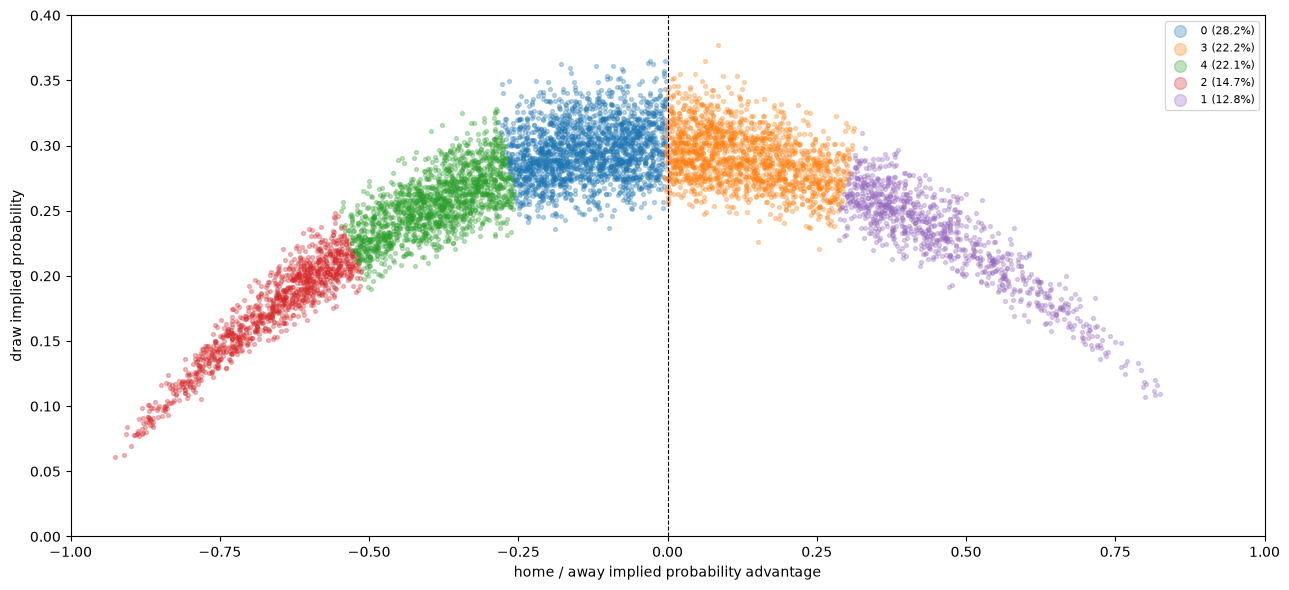

1997 0                    H: 43.3% ( -2.7%)  D: 28.9% ( -2.3%)  A: 27.8% (-10.2%)
1569 3                    H: 27.3% (-13.2%)  D: 27.9% ( -4.0%)  A: 44.7% ( +0.8%)
1564 4                    H: 56.6% ( -4.3%)  D: 25.5% ( -0.2%)  A: 17.9% (-11.9%)
1042 2                    H: 76.4% ( -0.5%)  D: 16.2% ( -7.3%)  A:  7.4% (-30.9%)
 909 1                    H: 13.5% (-24.7%)  D: 22.4% ( -2.7%)  A: 64.0% ( +0.1%)


In [7]:
from sklearn.cluster import KMeans

X = abt[impl_cols]

abt['cluster_kmeans'] = KMeans(n_clusters=5).fit_predict(X)

plot_impl_groups(abt, 'cluster_kmeans')

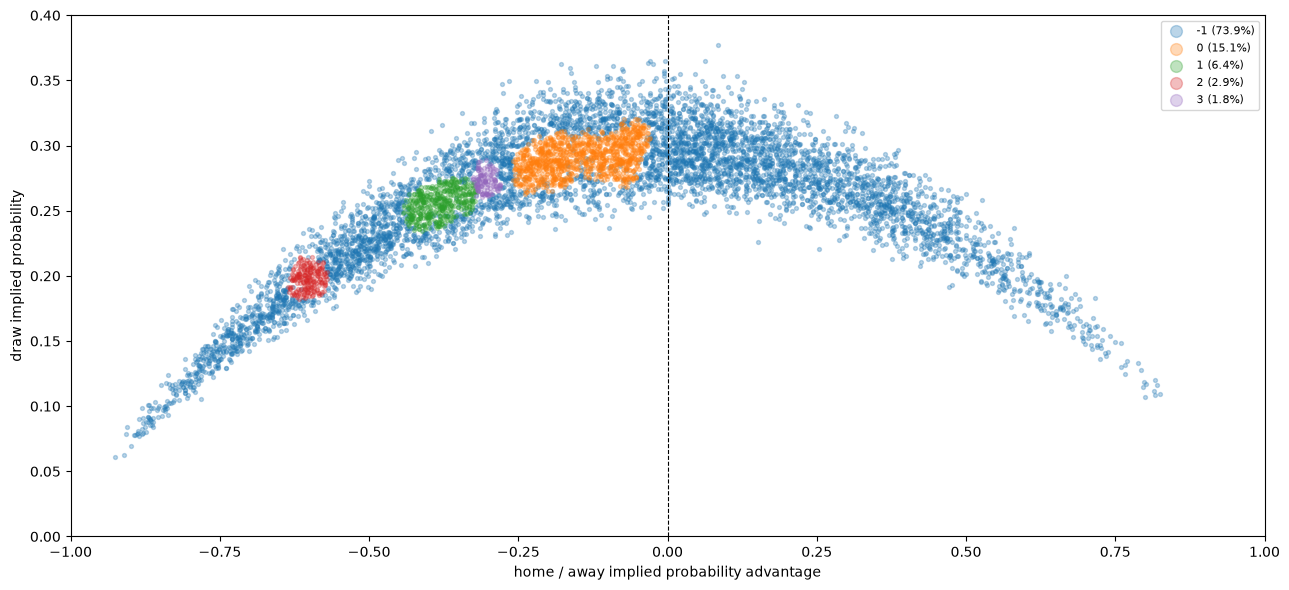

5233 -1                   H: 41.5% ( -5.9%)  D: 24.5% ( -4.4%)  A: 34.0% ( -3.7%)
1071 0                    H: 41.7% ( -7.4%)  D: 30.1% ( +3.4%)  A: 28.2% ( -8.3%)
 450 1                    H: 56.9% ( -3.2%)  D: 26.4% ( +3.3%)  A: 16.7% (-18.7%)
 202 2                    H: 77.2% ( +6.2%)  D: 14.9% (-24.9%)  A:  7.9% (-36.2%)
 125 3                    H: 52.8% ( -2.4%)  D: 29.6% ( +8.6%)  A: 17.6% (-25.3%)


In [8]:
from sklearn.cluster import DBSCAN

X = abt[impl_cols]

abt['cluster_dbscan'] = DBSCAN(eps=0.015, min_samples=100).fit_predict(X)

plot_impl_groups(abt, 'cluster_dbscan')

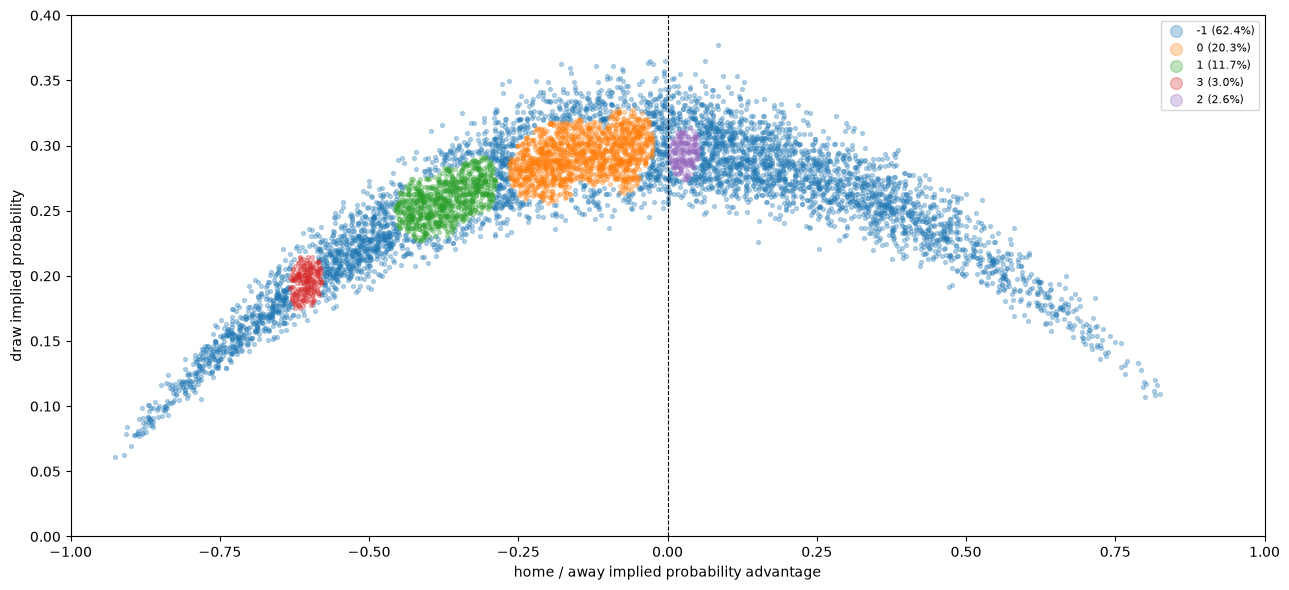

4421 -1                   H: 40.7% ( -6.3%)  D: 24.0% ( -4.3%)  A: 35.3% ( -3.2%)
1435 0                    H: 42.6% ( -5.3%)  D: 30.0% ( +2.6%)  A: 27.4% (-10.8%)
 829 1                    H: 57.2% ( -1.6%)  D: 25.1% ( -3.1%)  A: 17.7% (-15.4%)
 210 3                    H: 76.2% ( +4.4%)  D: 15.7% (-19.7%)  A:  8.1% (-34.5%)
 186 2                    H: 28.0% (-23.1%)  D: 29.6% ( +0.5%)  A: 42.5% ( +8.5%)


In [29]:
from sklearn.cluster import DBSCAN

X = abt[axis_cols]

abt['cluster_dbscan'] = DBSCAN(eps=0.016, min_samples=100).fit_predict(X)

plot_impl_groups(abt, 'cluster_dbscan')